In [1]:
# ============================================================
# İSTANBUL 39 İLÇE SU TÜKETİM TAHMİNİ - PROPHET
# Konut ve işyeri ayrı ayrı tahmin edilir, sonra toplanır
# ============================================================

In [2]:
# ── AŞAMA 1: KÜTÜPHANELERİ İÇE AKTAR ──────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('✅ Kütüphaneler yüklendi')

✅ Kütüphaneler yüklendi


In [3]:
# ── AŞAMA 2: DOSYA YOLLARI ─────────────────────────────────
ABONE_DOSYA    = r'C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\abone.xlsx'
SU_DOSYA       = r'C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\su_tuketim.xlsx'
SICAKLIK_DOSYA = r'C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\sicaklik.xlsx'

In [4]:
# ── AŞAMA 3: YARDIMCI FONKSİYON - TARİH PARSE ─────────────
AYLAR_TR = {
    'Ocak':1, 'Şubat':2, 'Mart':3, 'Nisan':4,
    'Mayıs':5, 'Haziran':6, 'Temmuz':7, 'Ağustos':8,
    'Eylül':9, 'Ekim':10, 'Kasım':11, 'Aralık':12
}

def tarih_parse(tarih_str):
    parcalar = str(tarih_str).strip().split()
    yil = int(parcalar[0])
    ay  = AYLAR_TR[parcalar[-1]]
    return pd.Timestamp(year=yil, month=ay, day=1)

In [5]:
# ── AŞAMA 4: ABONE VERİSİNİ YÜKLE ──────────────────────────
abone_raw = pd.read_excel(ABONE_DOSYA, header=1)

konut = abone_raw.iloc[:, 0:3].copy()
konut.columns = ['ilce', 'tarih', 'konut_abone']

isyeri = abone_raw.iloc[:, 8:11].copy()
isyeri.columns = ['ilce', 'tarih', 'isyeri_abone']

konut  = konut.dropna(subset=['ilce', 'tarih']).reset_index(drop=True)
isyeri = isyeri.dropna(subset=['ilce', 'tarih']).reset_index(drop=True)

konut['tarih']  = konut['tarih'].apply(tarih_parse)
isyeri['tarih'] = isyeri['tarih'].apply(tarih_parse)

abone_df = pd.merge(konut, isyeri, on=['ilce', 'tarih'], how='outer')
abone_df = abone_df[['ilce', 'tarih', 'konut_abone', 'isyeri_abone']]

print(f'✅ Abone verisi: {abone_df.shape[0]} satır, {abone_df["ilce"].nunique()} ilçe')

✅ Abone verisi: 2808 satır, 39 ilçe


In [6]:
# ── AŞAMA 5: SU TÜKETİM VERİSİNİ YÜKLE ────────────────────
su_raw = pd.read_excel(SU_DOSYA, header=1)

konut_su = su_raw.iloc[:, 0:3].copy()
konut_su.columns = ['ilce', 'tarih', 'konut_m3']

isyeri_su = su_raw.iloc[:, 4:7].copy()
isyeri_su.columns = ['ilce', 'tarih', 'isyeri_m3']

konut_su  = konut_su.dropna(subset=['ilce', 'tarih']).reset_index(drop=True)
isyeri_su = isyeri_su.dropna(subset=['ilce', 'tarih']).reset_index(drop=True)

konut_su['tarih']  = konut_su['tarih'].apply(tarih_parse)
isyeri_su['tarih'] = isyeri_su['tarih'].apply(tarih_parse)

konut_su['konut_m3']   = pd.to_numeric(konut_su['konut_m3'],   errors='coerce')
isyeri_su['isyeri_m3'] = pd.to_numeric(isyeri_su['isyeri_m3'], errors='coerce')

su_df = pd.merge(konut_su, isyeri_su, on=['ilce', 'tarih'], how='outer')
su_df = su_df[['ilce', 'tarih', 'konut_m3', 'isyeri_m3']]

print(f'✅ Su tüketim verisi: {su_df.shape[0]} satır, {su_df["ilce"].nunique()} ilçe')

✅ Su tüketim verisi: 2808 satır, 39 ilçe


In [7]:
# ── AŞAMA 6: SICAKLIK VERİSİNİ YÜKLE ───────────────────────
# header=1 → 2. satırı başlık olarak oku (ilk satır boş)
sicaklik_raw = pd.read_excel(SICAKLIK_DOSYA, header=1)

sicaklik_df = sicaklik_raw.rename(columns={
    "İLÇE": "ilce",
    "TARİH": "tarih",
    "ORTALAMA SICAKLIK": "sicaklik_c"
})

# "2020   Ocak" → datetime
tarih_split = sicaklik_df["tarih"].astype(str).str.strip().str.split(r"\s+", expand=True)
sicaklik_df["tarih"] = pd.to_datetime(
    tarih_split[0] + "-" + tarih_split[1].map(AYLAR_TR).astype(str),
    format="%Y-%m"
)

sicaklik_df["sicaklik_c"] = (
    sicaklik_df["sicaklik_c"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

sicaklik_df["ilce"] = sicaklik_df["ilce"].str.upper().str.strip()

print(f"✅ Sıcaklık verisi: {sicaklik_df.shape[0]} satır, {sicaklik_df['ilce'].nunique()} ilçe")

✅ Sıcaklık verisi: 2808 satır, 39 ilçe


In [8]:
# ── AŞAMA 7: İLÇE İSİMLERİNİ EŞLEŞTİR ─────────────────────
#eşleşmeyen ilçeler
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_abone    = set(abone_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())

print(f"Su verisi      : {len(ilce_su)} ilçe")
print(f"Abone verisi   : {len(ilce_abone)} ilçe")
print(f"Sıcaklık verisi: {len(ilce_sicaklik)} ilçe")

print("\n── Su ∩ Abone ──────────────────────────────")
print("🔴 Abonede olup suda OLMAYAN  :", ilce_abone - ilce_su)
print("🔵 Suda olup abonede OLMAYAN  :", ilce_su - ilce_abone)

print("\n── Su ∩ Sıcaklık ───────────────────────────")
print("🔴 Sıcaklıkta olup suda OLMAYAN  :", ilce_sicaklik - ilce_su)
print("🔵 Suda olup sıcaklıkta OLMAYAN  :", ilce_su - ilce_sicaklik)

print("\n── Üç sette birden olan ilçe sayısı ────────")
print("✅", len(ilce_su & ilce_abone & ilce_sicaklik), "ilçe tam eşleşiyor")

print("\n── Üç setten herhangi birinde eksik olanlar ─")
tum_ilceler = ilce_su | ilce_abone | ilce_sicaklik
eksik = {i: [] for i in tum_ilceler}
for i in tum_ilceler:
    if i not in ilce_su:       eksik[i].append("su yok")
    if i not in ilce_abone:    eksik[i].append("abone yok")
    if i not in ilce_sicaklik: eksik[i].append("sıcaklık yok")
eksik = {k: v for k, v in eksik.items() if v}
for ilce, sorun in sorted(eksik.items()):
    print(f"  {ilce:25s} → {', '.join(sorun)}")

Su verisi      : 39 ilçe
Abone verisi   : 39 ilçe
Sıcaklık verisi: 39 ilçe

── Su ∩ Abone ──────────────────────────────
🔴 Abonede olup suda OLMAYAN  : set()
🔵 Suda olup abonede OLMAYAN  : set()

── Su ∩ Sıcaklık ───────────────────────────
🔴 Sıcaklıkta olup suda OLMAYAN  : set()
🔵 Suda olup sıcaklıkta OLMAYAN  : set()

── Üç sette birden olan ilçe sayısı ────────
✅ 39 ilçe tam eşleşiyor

── Üç setten herhangi birinde eksik olanlar ─


In [9]:
# Aşama 7 sonrası doğrulama
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())
eksik = ilce_sicaklik - ilce_su
if eksik:
    print(f"⚠️  Hâlâ eşleşmeyen {len(eksik)} ilçe var: {eksik}")
else:
    print("✅ Tüm 39 ilçe eşleşiyor, devam edilebilir")

✅ Tüm 39 ilçe eşleşiyor, devam edilebilir


In [10]:
# ── AŞAMA 8: ÜÇ VERİYİ BİRLEŞTİR ──────────────────────────
df = (
    su_df
    .merge(abone_df,    on=['ilce', 'tarih'], how='inner')
    .merge(sicaklik_df, on=['ilce', 'tarih'], how='inner')
)

df = df[['ilce', 'tarih',
         'konut_m3', 'isyeri_m3',
         'konut_abone', 'isyeri_abone',
         'sicaklik_c']]

df['yil']  = df['tarih'].dt.year
df['ay']   = df['tarih'].dt.month
df['ilce'] = df['ilce'].str.upper().str.strip()

print(f'✅ Birleşik veri: {df.shape[0]} satır, {df["ilce"].nunique()} ilçe')
print(f'📅 Tarih aralığı: {df["tarih"].min().strftime("%Y-%m")} → {df["tarih"].max().strftime("%Y-%m")}')

✅ Birleşik veri: 2808 satır, 39 ilçe
📅 Tarih aralığı: 2020-01 → 2025-12


In [11]:
# ── AŞAMA 9: EĞİTİM / TEST BÖLÜNME ─────────────────────────
# Eğitim : 2020-01 → 2024-12
# Test   : 2025-01 → 2025-10  (10 ay)

EGITIM_BITIS   = '2024-12-01'
TEST_BASLANGIC = '2025-01-01'

df_train = df[df['tarih'] <= EGITIM_BITIS].copy()
df_test  = df[df['tarih'] >= TEST_BASLANGIC].copy()

ILCELER = sorted(df['ilce'].unique())
H = df_test['tarih'].nunique()

print(f'✅ Eğitim : {df_train["tarih"].min().strftime("%Y-%m")} → {df_train["tarih"].max().strftime("%Y-%m")}')
print(f'✅ Test   : {df_test["tarih"].min().strftime("%Y-%m")} → {df_test["tarih"].max().strftime("%Y-%m")}')
print(f'✅ Tahmin ufku: {H} ay  |  İlçe sayısı: {len(ILCELER)}')

✅ Eğitim : 2020-01 → 2024-12
✅ Test   : 2025-01 → 2025-12
✅ Tahmin ufku: 12 ay  |  İlçe sayısı: 39


In [12]:
# ── AŞAMA 10: METRİK FONKSİYONLARI ─────────────────────────
def mape(gercek, tahmin):
    mask = gercek != 0
    return np.mean(np.abs((gercek[mask] - tahmin[mask]) / gercek[mask])) * 100

def rmse(gercek, tahmin):
    return np.sqrt(mean_squared_error(gercek, tahmin))

def mae(gercek, tahmin):
    return mean_absolute_error(gercek, tahmin)

# Gerçek değer tablosu
gercek_df = df_test[['ilce', 'tarih', 'konut_m3', 'isyeri_m3']].copy()
gercek_df['toplam_gercek'] = gercek_df['konut_m3'] + gercek_df['isyeri_m3']
gercek_df = gercek_df.rename(columns={
    'konut_m3' : 'konut_gercek',
    'isyeri_m3': 'isyeri_gercek'
})

print('✅ Metrik fonksiyonları ve gerçek değer tablosu hazır')

✅ Metrik fonksiyonları ve gerçek değer tablosu hazır


In [13]:
# ── AŞAMA 11: PROPHET TAHMİN FONKSİYONU ─────────────────────
# seasonality_mode = 'multiplicative'  →  su tüketiminde mevsimsel
#                                          etki oransal olduğundan
#                                          additive'e göre daha isabetli
# Regressor: sicaklik_c, konut_abone, isyeri_abone

def prophet_tahmin(df_train, df_test, hedef_col, ilce):
    """
    Tek ilçe, tek hedef sütun için Prophet modeli kurar ve tahmin döndürür.
    Döndürür: (tahmin_df, model)
    """
    # Eğitim verisi — Prophet ds/y formatına çevir
    egitim = df_train[df_train['ilce'] == ilce][[
        'tarih', hedef_col, 'sicaklik_c', 'konut_abone', 'isyeri_abone'
    ]].copy()
    egitim = egitim.rename(columns={'tarih': 'ds', hedef_col: 'y'})
    egitim = egitim.dropna()

    # Test exog verileri
    test = df_test[df_test['ilce'] == ilce][[
        'tarih', 'sicaklik_c', 'konut_abone', 'isyeri_abone'
    ]].copy()
    test = test.rename(columns={'tarih': 'ds'})

    # Model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=10.0,
    )
    model.add_regressor('sicaklik_c')
    model.add_regressor('konut_abone')
    model.add_regressor('isyeri_abone')
    model.fit(egitim)

    tahmin = model.predict(test)
    return tahmin[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy(), model

print('✅ Prophet fonksiyonu tanımlandı')

✅ Prophet fonksiyonu tanımlandı


In [14]:
# ── AŞAMA 12: PROPHET TAHMİNİ — TÜM İLÇELER ────────────────
# Konut ve işyeri ayrı ayrı tahmin edilir, sonra toplanır

prophet_sonuclar = []

for ilce in ILCELER:
    try:
        # Konut tahmini
        tahmin_k, _ = prophet_tahmin(df_train, df_test, 'konut_m3', ilce)
        tahmin_k = tahmin_k.rename(columns={
            'yhat'       : 'konut_tahmin',
            'yhat_lower' : 'konut_lo',
            'yhat_upper' : 'konut_hi',
        })

        # İşyeri tahmini
        tahmin_i, _ = prophet_tahmin(df_train, df_test, 'isyeri_m3', ilce)
        tahmin_i = tahmin_i.rename(columns={
            'yhat'       : 'isyeri_tahmin',
            'yhat_lower' : 'isyeri_lo',
            'yhat_upper' : 'isyeri_hi',
        })

        # Birleştir
        tek = tahmin_k.merge(tahmin_i, on='ds')
        tek['ilce']          = ilce
        tek['toplam_tahmin'] = tek['konut_tahmin'] + tek['isyeri_tahmin']
        tek['toplam_lo']     = tek['konut_lo']     + tek['isyeri_lo']
        tek['toplam_hi']     = tek['konut_hi']     + tek['isyeri_hi']

        prophet_sonuclar.append(tek)
        print(f'  ✅ {ilce}')
    except Exception as e:
        print(f'  ❌ {ilce}: {e}')

prophet_df = pd.concat(prophet_sonuclar).reset_index(drop=True)
prophet_df = prophet_df.rename(columns={'ds': 'tarih'})
print(f'\n✅ Prophet tahminleri tamamlandı: {prophet_df.shape[0]} satır')

17:51:33 - cmdstanpy - INFO - Chain [1] start processing
17:51:35 - cmdstanpy - INFO - Chain [1] done processing
17:51:35 - cmdstanpy - INFO - Chain [1] start processing
17:51:36 - cmdstanpy - INFO - Chain [1] done processing
17:51:36 - cmdstanpy - INFO - Chain [1] start processing


  ✅ ADALAR


17:51:36 - cmdstanpy - INFO - Chain [1] done processing
17:51:37 - cmdstanpy - INFO - Chain [1] start processing
17:51:37 - cmdstanpy - INFO - Chain [1] done processing
17:51:37 - cmdstanpy - INFO - Chain [1] start processing


  ✅ ARNAVUTKÖY


17:51:38 - cmdstanpy - INFO - Chain [1] done processing
17:51:38 - cmdstanpy - INFO - Chain [1] start processing
17:51:38 - cmdstanpy - INFO - Chain [1] done processing
17:51:39 - cmdstanpy - INFO - Chain [1] start processing


...

  ✅ ÜSKÜDAR


17:52:27 - cmdstanpy - INFO - Chain [1] done processing
17:52:27 - cmdstanpy - INFO - Chain [1] start processing
17:52:27 - cmdstanpy - INFO - Chain [1] done processing
17:52:28 - cmdstanpy - INFO - Chain [1] start processing


  ✅ ŞİLE


17:52:28 - cmdstanpy - INFO - Chain [1] done processing
17:52:28 - cmdstanpy - INFO - Chain [1] start processing
17:52:29 - cmdstanpy - INFO - Chain [1] done processing


  ✅ ŞİŞLİ

✅ Prophet tahminleri tamamlandı: 468 satır


In [15]:
# ── AŞAMA 13: GERÇEK DEĞERLERLE BİRLEŞTİR ──────────────────
karsilastirma = prophet_df.merge(gercek_df, on=['ilce', 'tarih'], how='inner')

print(f'✅ Karşılaştırma tablosu: {karsilastirma.shape[0]} satır')

✅ Karşılaştırma tablosu: 468 satır


In [16]:
# ── AŞAMA 14: PERFORMANS DEĞERLENDİRMESİ ────────────────────

prophet_kar = prophet_df.merge(
    gercek_df,
    on=["ilce", "tarih"],
    how="inner"
)

prophet_metrikler = []

for ilce in ILCELER:

    k = prophet_kar[prophet_kar["ilce"] == ilce].copy()

    if k.empty:
        continue

    # ── NAN TEMİZLİĞİ ─────────────────────────────
    k = k.dropna(subset=[
        "konut_gercek", "konut_tahmin",
        "isyeri_gercek", "isyeri_tahmin",
        "toplam_gercek", "toplam_tahmin"
    ])

    if k.empty:
        continue

    # ── METRİKLER ────────────────────────────────
    prophet_metrikler.append({
        "ilce": ilce,

        "MAPE_Konut": mape(
            k["konut_gercek"].values,
            k["konut_tahmin"].values
        ),

        "MAPE_Isyeri": mape(
            k["isyeri_gercek"].values,
            k["isyeri_tahmin"].values
        ),

        "MAPE_Toplam": mape(
            k["toplam_gercek"].values,
            k["toplam_tahmin"].values
        ),

        "MAE_Konut": mae(
            k["konut_gercek"].values,
            k["konut_tahmin"].values
        ),

        "MAE_Isyeri": mae(
            k["isyeri_gercek"].values,
            k["isyeri_tahmin"].values
        ),

        "MAE_Toplam": mae(
            k["toplam_gercek"].values,
            k["toplam_tahmin"].values
        ),

        "RMSE_Konut": rmse(
            k["konut_gercek"].values,
            k["konut_tahmin"].values
        ),

        "RMSE_Isyeri": rmse(
            k["isyeri_gercek"].values,
            k["isyeri_tahmin"].values
        ),

        "RMSE_Toplam": rmse(
            k["toplam_gercek"].values,
            k["toplam_tahmin"].values
        ),
    })

prophet_metrikler_df = (
    pd.DataFrame(prophet_metrikler)
    .sort_values("MAPE_Toplam")
)

print("\n📊 PROPHET — İLÇE BAZLI PERFORMANS:")
print(prophet_metrikler_df.to_string(index=False))

print(f"\n🎯 Prophet Ort. MAPE  Konut  : {prophet_metrikler_df['MAPE_Konut'].mean():.2f}%")
print(f"🎯 Prophet Ort. MAPE  İşyeri : {prophet_metrikler_df['MAPE_Isyeri'].mean():.2f}%")
print(f"🎯 Prophet Ort. MAPE  Toplam : {prophet_metrikler_df['MAPE_Toplam'].mean():.2f}%")
print(f"🎯 Prophet Ort. MAE   Toplam : {prophet_metrikler_df['MAE_Toplam'].mean():,.0f} m³")
print(f"🎯 Prophet Ort. RMSE  Toplam : {prophet_metrikler_df['RMSE_Toplam'].mean():,.0f} m³")


📊 PROPHET — İLÇE BAZLI PERFORMANS:
        ilce  MAPE_Konut  MAPE_Isyeri  MAPE_Toplam     MAE_Konut    MAE_Isyeri    MAE_Toplam    RMSE_Konut  RMSE_Isyeri  RMSE_Toplam
    ATAŞEHİR    5.866817    12.097755     6.920875  80413.991799  58001.056983 128716.066720 135678.281511 7.264152e+04 1.916992e+05
    G.O.PAŞA    7.488482    13.680160     7.244539  98304.809749  29157.543882 108046.279389 162587.098110 4.012791e+04 1.931289e+05
BAHÇELİEVLER    8.085133    12.436531     7.501189 139255.274517  51855.265289 158643.879944 196655.516942 6.712186e+04 2.413650e+05
     ESENLER    8.845053    15.936188     7.548819 107826.761921  37319.553529 109039.707760 164021.815532 4.503374e+04 1.791210e+05
   KAĞITHANE    8.472187    17.300956     7.555770 121185.538297  58517.413807 138492.841695 170263.118383 7.166522e+04 1.920699e+05
    ESENYURT    9.279144     8.154094     7.624805 289903.125935 103616.336915 332872.216141 428327.571319 1.356520e+05 4.756981e+05
  BAYRAMPAŞA    7.779665    12.12

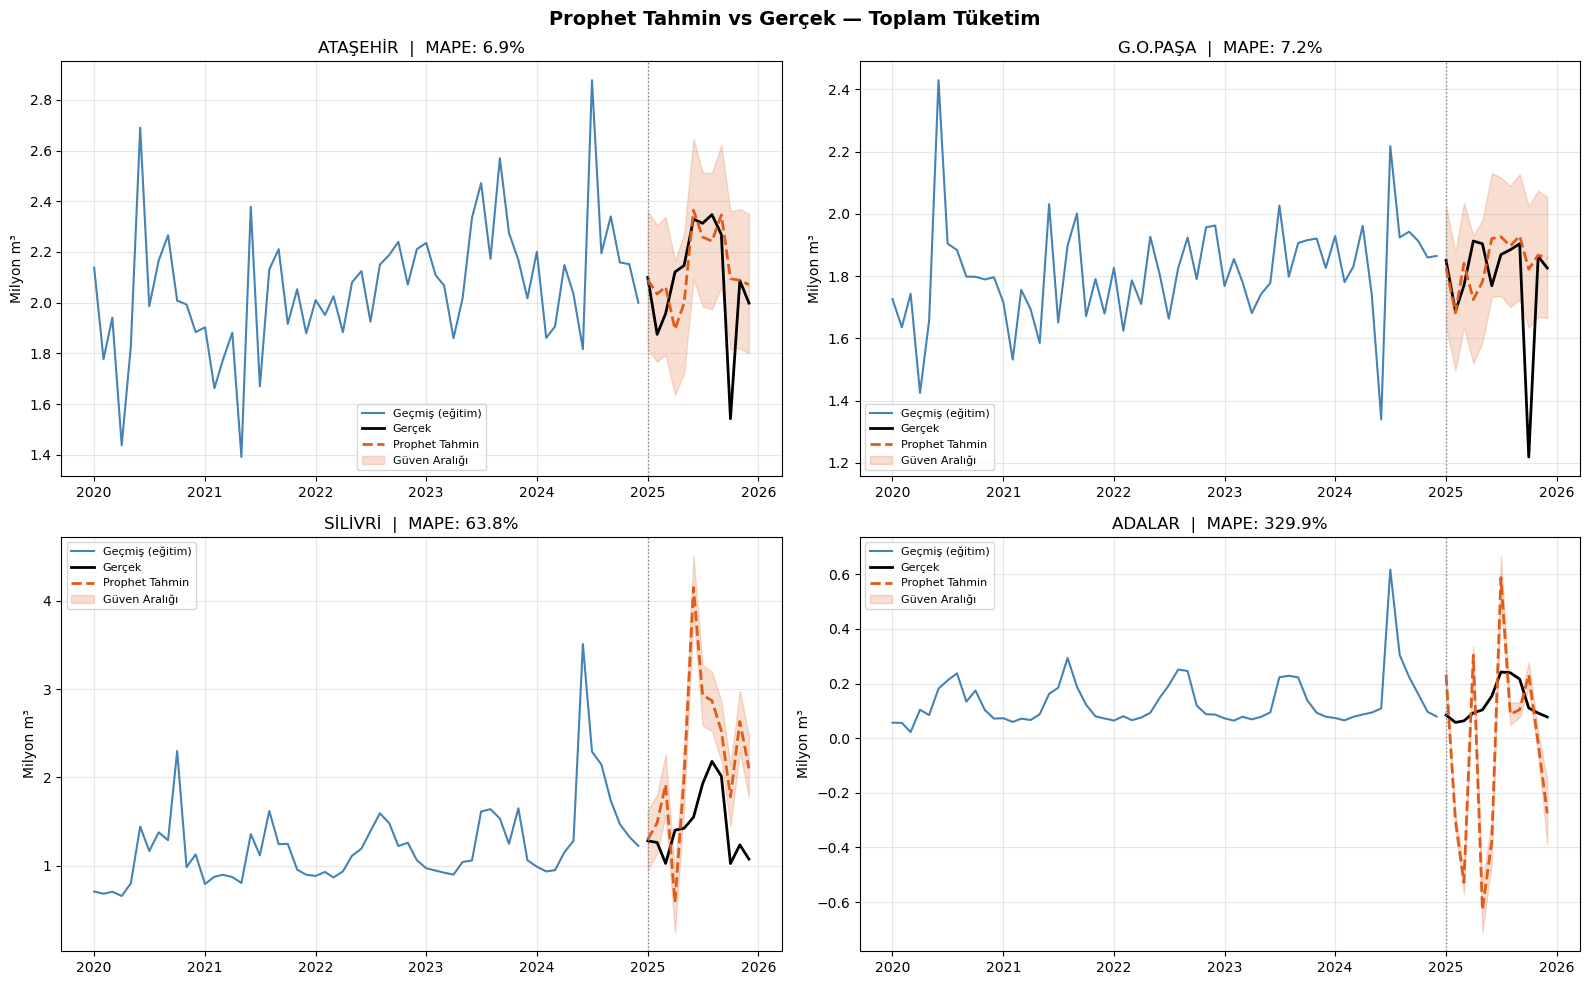

✅ Prophet grafikleri kaydedildi: prophet_tahmin_grafikleri.png


In [17]:
# ── AŞAMA 15: TAHMİN GRAFİKLERİ ────────────────────────────
en_iyi  = prophet_metrikler_df.head(2)['ilce'].tolist()
en_kotu = prophet_metrikler_df.tail(2)['ilce'].tolist()
gosterilecek = en_iyi + en_kotu

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Prophet Tahmin vs Gerçek — Toplam Tüketim', fontsize=14, fontweight='bold')

for ax, ilce in zip(axes.flatten(), gosterilecek):

    gecmis = df_train[df_train['ilce'] == ilce].copy()
    gecmis['toplam'] = gecmis['konut_m3'] + gecmis['isyeri_m3']

    k = karsilastirma[karsilastirma['ilce'] == ilce]

    mape_val = prophet_metrikler_df[
        prophet_metrikler_df['ilce'] == ilce
    ]['MAPE_Toplam'].values[0]

    ax.plot(
        gecmis['tarih'], gecmis['toplam'] / 1e6,
        color='steelblue', linewidth=1.5, label='Geçmiş (eğitim)'
    )

    ax.plot(
        k['tarih'], k['toplam_gercek'] / 1e6,
        color='black', linewidth=2, label='Gerçek'
    )

    ax.plot(
        k['tarih'], k['toplam_tahmin'] / 1e6,
        color='#e05c1a', linewidth=2, linestyle='--', label='Prophet Tahmin'
    )

    ax.fill_between(
        k['tarih'],
        k['toplam_lo'] / 1e6,
        k['toplam_hi'] / 1e6,
        alpha=0.2,
        color='#e05c1a',
        label='Güven Aralığı'
    )

    ax.axvline(pd.Timestamp('2025-01-01'),
               color='gray',
               linestyle=':',
               linewidth=1)

    ax.set_title(f'{ilce}  |  MAPE: {mape_val:.1f}%')
    ax.set_ylabel('Milyon m³')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prophet_tahmin_grafikleri.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Prophet grafikleri kaydedildi: prophet_tahmin_grafikleri.png')

In [18]:
# ── AŞAMA 16: SONUÇLARI EXCEL'E KAYDET ─────────────────────
CIKTI_DOSYASI = r'C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_prophet.xlsx'

# Eğitim dönemi bağlam verilerini hazırla (TimeGPT formatıyla uyumlu)
baglam_konut  = df_train[['ilce', 'tarih', 'konut_m3',  'sicaklik_c', 'konut_abone', 'isyeri_abone']].copy()
baglam_isyeri = df_train[['ilce', 'tarih', 'isyeri_m3', 'sicaklik_c', 'konut_abone', 'isyeri_abone']].copy()

# Kolon adını unique_id'ye çevir (karşılaştırma notebook'uyla uyumlu)
karsilastirma_xl      = karsilastirma.rename(columns={'ilce': 'unique_id', 'tarih': 'ds'})
prophet_metrikler_xl  = prophet_metrikler_df.rename(columns={'ilce': 'unique_id'})
prophet_df_xl         = prophet_df.rename(columns={'ilce': 'unique_id', 'tarih': 'ds'})
baglam_konut_xl       = baglam_konut.rename(columns={'ilce': 'unique_id', 'tarih': 'ds'})
baglam_isyeri_xl      = baglam_isyeri.rename(columns={'ilce': 'unique_id', 'tarih': 'ds'})
ham_veri_xl           = df.rename(columns={'ilce': 'unique_id', 'tarih': 'ds'})

with pd.ExcelWriter(CIKTI_DOSYASI, engine='openpyxl') as writer:
    karsilastirma_xl.to_excel(     writer, sheet_name='Tahmin vs Gerçek', index=False)
    prophet_metrikler_xl.to_excel( writer, sheet_name='Performans',        index=False)
    prophet_df_xl.to_excel(        writer, sheet_name='Tahminler',         index=False)
    baglam_konut_xl.to_excel(      writer, sheet_name='Bağlam Konut',      index=False)
    baglam_isyeri_xl.to_excel(     writer, sheet_name='Bağlam İşyeri',     index=False)
    ham_veri_xl.to_excel(          writer, sheet_name='Ham Veri',           index=False)

print(f'✅ Excel kaydedildi: {CIKTI_DOSYASI}')
print('\n🎉 Prophet işlemi tamamlandı!')

✅ Excel kaydedildi: C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_prophet.xlsx

🎉 Prophet işlemi tamamlandı!
